In [20]:
import pandas as pd
import numpy as np

In [21]:
df= pd.read_csv('spam.csv', encoding='latin-1')

In [22]:
df.head(4)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [24]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [25]:
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [26]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1281,ham,Am I the only one who doesn't stalk profiles?
1390,ham,"I wonder how you got online, my love ? Had you..."
2727,ham,Whatsup there. Dont u want to sleep
4074,ham,"God picked up a flower and dippeditinaDEW, lov..."
5284,ham,Sent me ur email id soon


In [27]:
df['target'].value_counts()

target
ham     4825
spam     747
Name: count, dtype: int64

In [29]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(403)

In [35]:
df= df.drop_duplicates(keep='first')

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le= LabelEncoder()

In [38]:
df['target']= le.fit_transform(df['target'])

In [40]:
df.sample(5)

,target,text
3635,0,\ME 2 BABE I FEEL THE SAME LETS JUST 4GET ABOU...
4852,0,I'm fine. Hope you are also
5531,0,Compliments to you. Was away from the system. ...
4262,0,Den only weekdays got special price... Haiz......
3805,1,URGENT! We are trying to contact you. Last wee...


<b><h3>EDA

In [41]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

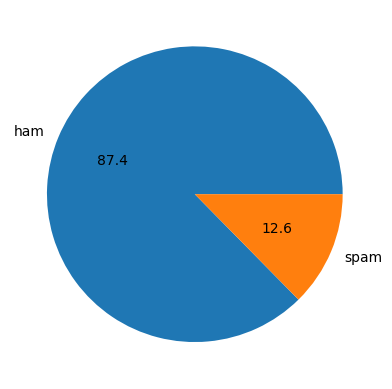

In [43]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'], autopct= '%1.1f')
plt.show()

In [44]:
import nltk

In [45]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Sufiyan
[nltk_data]     Asif\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [48]:
df['num_characters']= df['text'].apply(len)

In [52]:
df['num_of_words']= df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [53]:
df['num_of_sentence']= df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [54]:
df.sample(5)

,target,text,num_characters,num_of_words,num_of_sentence
5312,0,Here got ur favorite oyster... N got my favori...,121,25,2
1633,0,Yesterday its with me only . Now am going home.,47,11,2
1223,0,Rofl betta invest in some anti aging products,46,8,1
3645,0,Carlos says we can pick up from him later so y...,59,14,1
129,0,K..k:)how much does it cost?,28,11,1


In [56]:
df[df['target']==0][['num_characters','num_of_words','num_of_sentence']].describe()

,num_characters,num_of_words,num_of_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [58]:
df[df['target']==1][['num_characters','num_of_words','num_of_sentence']].describe()

,num_characters,num_of_words,num_of_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

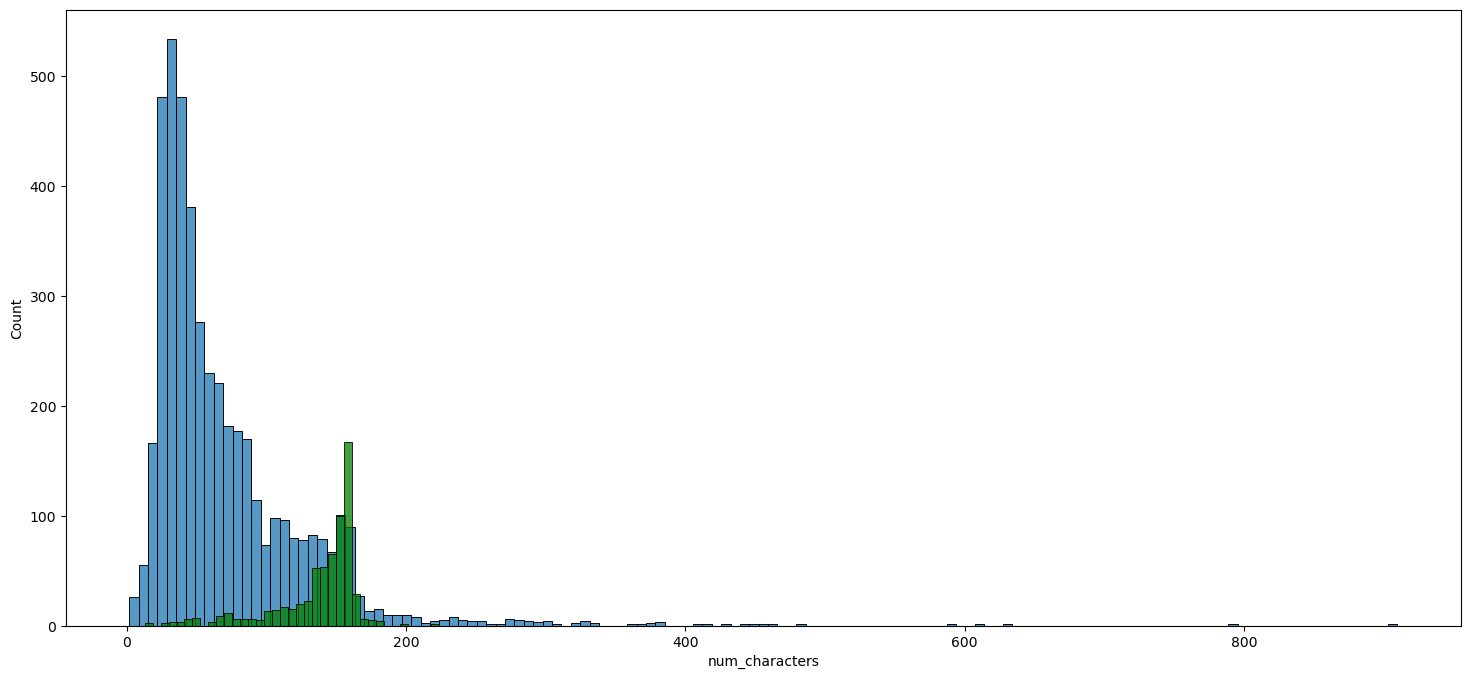

In [62]:
import seaborn as sns
plt.figure(figsize=(18,8))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'], color='green')

<Axes: xlabel='num_of_words', ylabel='Count'>

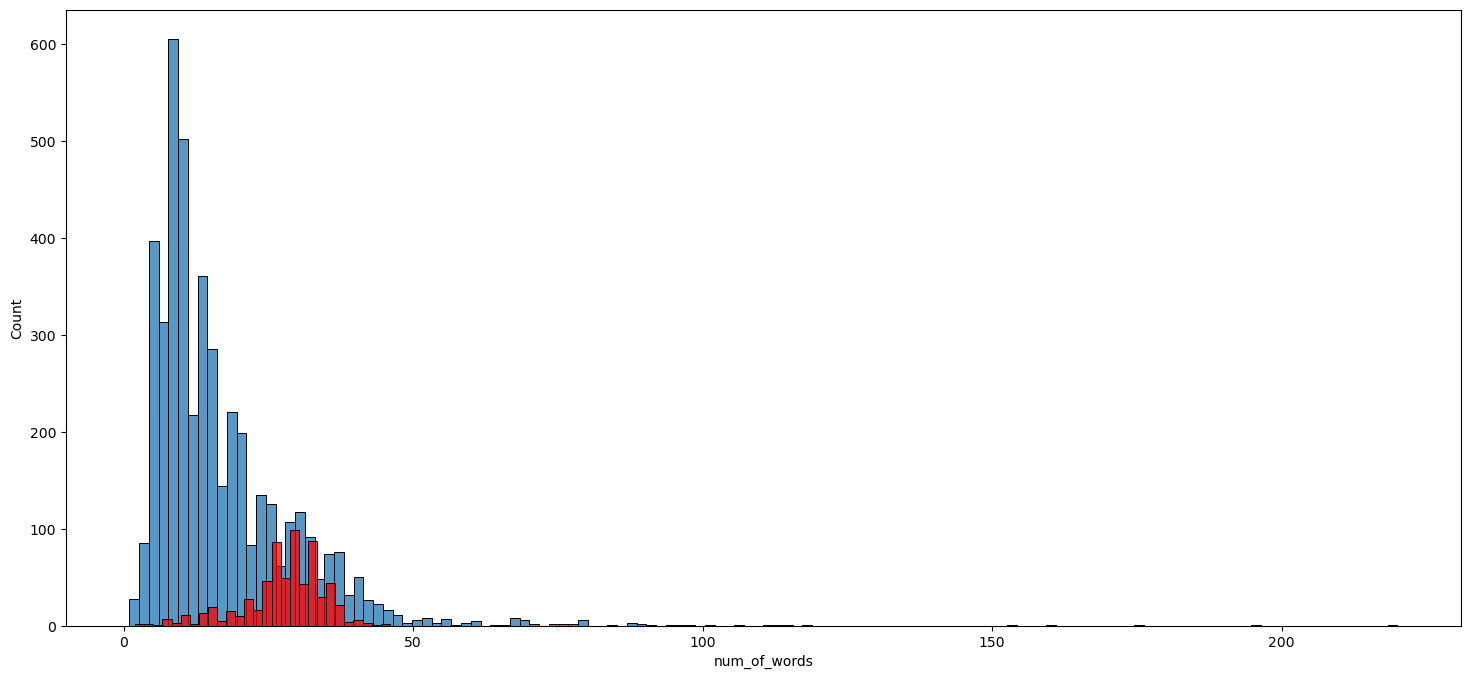

In [63]:
plt.figure(figsize=(18,8))
sns.histplot(df[df['target']==0]['num_of_words'])
sns.histplot(df[df['target']==1]['num_of_words'], color='red')

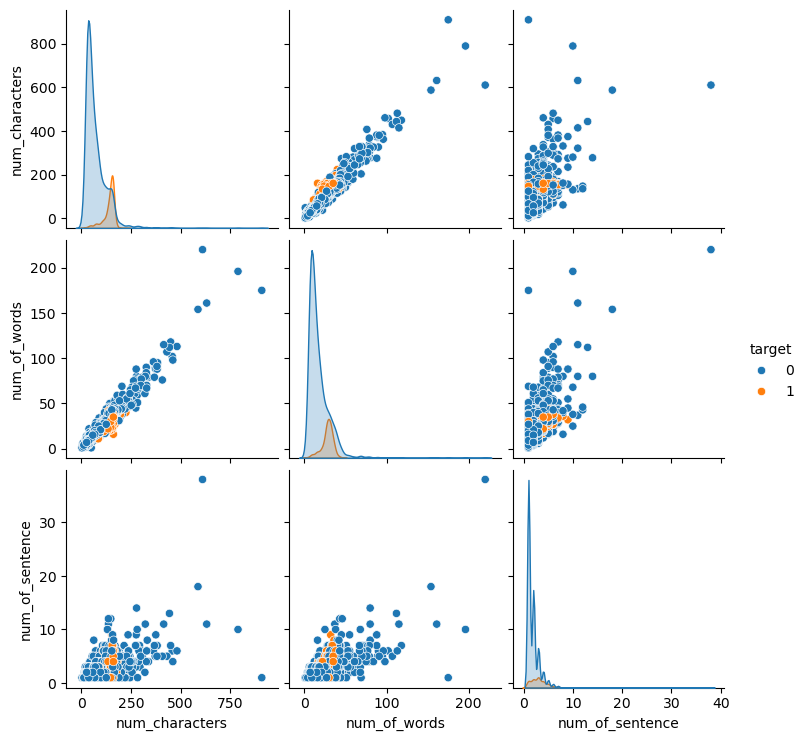

In [64]:
sns.pairplot(df, hue='target')

<b><h4>Text Cleaning

In [71]:
def clean_text(text):
    import string
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    from nltk.tokenize import word_tokenize

    ps = PorterStemmer()
    stop_words = stopwords.words('english')

    text= text.lower()
    tokens= word_tokenize(text)

    tokens= [word for word in tokens  if word.isalnum() ]
    tokens= [word for word in tokens if word not in stop_words]
    tokens= [ps.stem(word) for word in tokens]

    return " ".join(tokens)

In [72]:
df['Preprocesssed_text']= df['text'].apply(clean_text)

In [73]:
df.head(4)

,target,text,num_characters,num_of_words,num_of_sentence,Preprocesssed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say


In [75]:
wc= WordCloud(width=500, height=500,background_color='white')

In [78]:
spam_wc = wc.generate(df[df['target'] == 1]['Preprocesssed_text'].str.cat(sep=" "))

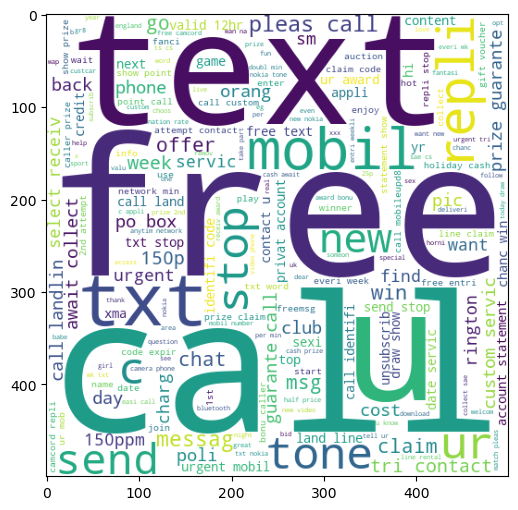

In [80]:
plt.figure(figsize=(13,6))
plt.imshow(spam_wc)

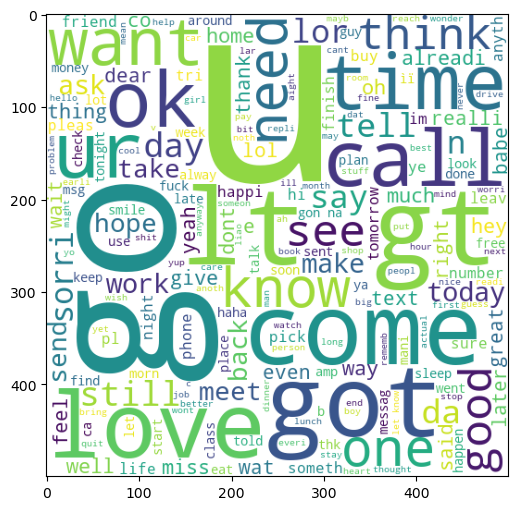

In [82]:
ham_wc = wc.generate(df[df['target'] == 0]['Preprocesssed_text'].str.cat(sep=" "))
plt.figure(figsize=(13,6))
plt.imshow(spam_wc)